# Resort vs City Hotels

## Análisis de precios y ocupaciones en hoteles según estilo de Hotel

Este proyecto analizará patrones en datos históricos sobre ocupaciones, cancelaciones y tarifas de dos hoteles: un resort y un hotel citadino, para identificar diferencias claves en estacionalidad, cancelación, precios y comportamientos del cliente. 

# Introducción

## Objetivo del análisis

Analizar y comparar patrones de demanda, precios y cancelaciones entre un hotel resort y un hotel urbano, utilizando datos históricos de reservas (2015-2017), con el fin de identificar diferencias en el comportamiento de los clientes y generar recomendaciones que apoyen la toma de decisiones en contextos turísticos. 

## Preguntas de negocio

1. ¿Cómo varía la demanda hotelera a lo largo del año en un hotel resort y en un hotel urbano?
2. ¿Existen diferencias en la estacionalidad entre ambos tipos de hotel?
3. ¿Qué tipo de hotel presenta una mayor tasa de cancelación?
4. ¿La anticipación de reserva influye de manera distinta en las cancelaciones según el tipo de hotel?
5. ¿Qué diferencias hay en el precio promedio por noche (ADR) entre cada hotel?

## Dataset

El análisis utiliza el dataset **Hotel Booking Demand**, un artículo publicado en línea en 2018 con información histórica del 2015 de reservaciones de dos hoteles en Portugal que incluye fechas de llegada, precios promedio por noche (ADR), tipo de cliente y estatus de cancelación.

El dataset no se considerará exclusivamente para ningún destino turístico, pero se utilizará como un caso representativo.
Cabe recalcar que estos datos se tomarán en cuenta para hacer insights decisivos al día de hoy, aunque la información con la que se cuenta existe en un contexto más antiguo. 

# Exploración inicial de los datos

In [1]:
# Carga de librerías

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

### Hotel Resort

In [2]:
# Se observarán los datos con los que contamos de manera breve
resort = pd.read_csv('/Users/RPA/Documents/Personal-DA-Proyects/hotel-vacancy-cancun/data/H1.csv')
resort.head()
resort.tail()

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,...,DepositType,Agent,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate
40055,0,212,2017,August,35,31,2,8,2,1,...,No Deposit,143,NULL,0,Transient,89.75,0,0,Check-Out,2017-09-10
40056,0,169,2017,August,35,30,2,9,2,0,...,No Deposit,250,NULL,0,Transient-Party,202.27,0,1,Check-Out,2017-09-10
40057,0,204,2017,August,35,29,4,10,2,0,...,No Deposit,250,NULL,0,Transient,153.57,0,3,Check-Out,2017-09-12
40058,0,211,2017,August,35,31,4,10,2,0,...,No Deposit,40,NULL,0,Contract,112.80,0,1,Check-Out,2017-09-14
40059,0,161,2017,August,35,31,4,10,2,0,...,No Deposit,69,NULL,0,Transient,99.06,0,0,Check-Out,2017-09-14


In [3]:
resort.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40060 entries, 0 to 40059
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   IsCanceled                   40060 non-null  int64  
 1   LeadTime                     40060 non-null  int64  
 2   ArrivalDateYear              40060 non-null  int64  
 3   ArrivalDateMonth             40060 non-null  object 
 4   ArrivalDateWeekNumber        40060 non-null  int64  
 5   ArrivalDateDayOfMonth        40060 non-null  int64  
 6   StaysInWeekendNights         40060 non-null  int64  
 7   StaysInWeekNights            40060 non-null  int64  
 8   Adults                       40060 non-null  int64  
 9   Children                     40060 non-null  int64  
 10  Babies                       40060 non-null  int64  
 11  Meal                         40060 non-null  object 
 12  Country                      39596 non-null  object 
 13  MarketSegment   

In [4]:
# Se observarán los valores nulos del dataset
print(resort['Country'].unique())
# Ya que el país de origen de los clientes no es relevante para este proyecto, se reemplazarán los valores nulos con "N/A" en vez de eliminar esos registros. 
resort['Country'] = resort['Country'].fillna('N/A')
resort.info()

['PRT' 'GBR' 'USA' 'ESP' 'IRL' 'FRA' nan 'ROU' 'NOR' 'OMN' 'ARG' 'POL'
 'DEU' 'BEL' 'CHE' 'CN' 'GRC' 'ITA' 'NLD' 'DNK' 'RUS' 'SWE' 'AUS' 'EST'
 'CZE' 'BRA' 'FIN' 'MOZ' 'BWA' 'LUX' 'SVN' 'ALB' 'IND' 'CHN' 'MEX' 'MAR'
 'UKR' 'SMR' 'LVA' 'PRI' 'SRB' 'CHL' 'AUT' 'BLR' 'LTU' 'TUR' 'ZAF' 'AGO'
 'ISR' 'CYM' 'ZMB' 'CPV' 'ZWE' 'DZA' 'KOR' 'CRI' 'HUN' 'ARE' 'TUN' 'JAM'
 'HRV' 'HKG' 'IRN' 'GEO' 'AND' 'GIB' 'URY' 'JEY' 'CAF' 'CYP' 'COL' 'GGY'
 'KWT' 'NGA' 'MDV' 'VEN' 'SVK' 'FJI' 'KAZ' 'PAK' 'IDN' 'LBN' 'PHL' 'SEN'
 'SYC' 'AZE' 'BHR' 'NZL' 'THA' 'DOM' 'MKD' 'MYS' 'ARM' 'JPN' 'LKA' 'CUB'
 'CMR' 'BIH' 'MUS' 'COM' 'SUR' 'UGA' 'BGR' 'CIV' 'JOR' 'SYR' 'SGP' 'BDI'
 'SAU' 'VNM' 'PLW' 'QAT' 'EGY' 'PER' 'MLT' 'MWI' 'ECU' 'MDG' 'ISL' 'UZB'
 'NPL' 'BHS' 'MAC' 'TGO' 'TWN' 'DJI']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40060 entries, 0 to 40059
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   IsCan

In [5]:
# Se creará una columna de fecha tipo datetime para facilitar el análisis
resort['arrival_date'] = pd.to_datetime(resort['ArrivalDateYear'].astype(str)+ '-' + 
                                        resort['ArrivalDateMonth'].astype(str)+'-'+ resort['ArrivalDateDayOfMonth'].astype(str))
resort['arrival_month'] = pd.to_datetime(resort['ArrivalDateYear'].astype(str)+'-'+resort['ArrivalDateMonth'].astype(str), format='%Y-%B')
resort.head()

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,...,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate,arrival_date,arrival_month
0,0,342,2015,July,27,1,0,0,2,0,...,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-01,2015-07-01
1,0,737,2015,July,27,1,0,0,2,0,...,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-01,2015-07-01
2,0,7,2015,July,27,1,0,1,1,0,...,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-01,2015-07-01
3,0,13,2015,July,27,1,0,1,1,0,...,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-01,2015-07-01
4,0,14,2015,July,27,1,0,2,2,0,...,NULL,0,Transient,98.0,0,1,Check-Out,2015-07-03,2015-07-01,2015-07-01


### Hotel Urbano

In [6]:
city = pd.read_csv('/Users/RPA/Documents/Personal-DA-Proyects/hotel-vacancy-cancun/data/H2.csv')
city.head()

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,...,DepositType,Agent,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate
0,0,6,2015,July,27,1,0,2,1,0.0,...,No Deposit,6,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-03
1,1,88,2015,July,27,1,0,4,2,0.0,...,No Deposit,9,NULL,0,Transient,76.5,0,1,Canceled,2015-07-01
2,1,65,2015,July,27,1,0,4,1,0.0,...,No Deposit,9,NULL,0,Transient,68.0,0,1,Canceled,2015-04-30
3,1,92,2015,July,27,1,2,4,2,0.0,...,No Deposit,9,NULL,0,Transient,76.5,0,2,Canceled,2015-06-23
4,1,100,2015,July,27,2,0,2,2,0.0,...,No Deposit,9,NULL,0,Transient,76.5,0,1,Canceled,2015-04-02


In [7]:
city.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79330 entries, 0 to 79329
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   IsCanceled                   79330 non-null  int64  
 1   LeadTime                     79330 non-null  int64  
 2   ArrivalDateYear              79330 non-null  int64  
 3   ArrivalDateMonth             79330 non-null  object 
 4   ArrivalDateWeekNumber        79330 non-null  int64  
 5   ArrivalDateDayOfMonth        79330 non-null  int64  
 6   StaysInWeekendNights         79330 non-null  int64  
 7   StaysInWeekNights            79330 non-null  int64  
 8   Adults                       79330 non-null  int64  
 9   Children                     79326 non-null  float64
 10  Babies                       79330 non-null  int64  
 11  Meal                         79330 non-null  object 
 12  Country                      79306 non-null  object 
 13  MarketSegment   

In [8]:
# Se creará una columna de fecha tipo datetime para facilitar el análisis
city['arrival_date'] = pd.to_datetime(city['ArrivalDateYear'].astype(str)+ '-' + 
                                        city['ArrivalDateMonth'].astype(str)+'-'+ city['ArrivalDateDayOfMonth'].astype(str))
city['arrival_month'] = pd.to_datetime(city['ArrivalDateYear'].astype(str)+'-'+city['ArrivalDateMonth'].astype(str), format='%Y-%B')
city.head()

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,...,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate,arrival_date,arrival_month
0,0,6,2015,July,27,1,0,2,1,0.0,...,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-03,2015-07-01,2015-07-01
1,1,88,2015,July,27,1,0,4,2,0.0,...,NULL,0,Transient,76.5,0,1,Canceled,2015-07-01,2015-07-01,2015-07-01
2,1,65,2015,July,27,1,0,4,1,0.0,...,NULL,0,Transient,68.0,0,1,Canceled,2015-04-30,2015-07-01,2015-07-01
3,1,92,2015,July,27,1,2,4,2,0.0,...,NULL,0,Transient,76.5,0,2,Canceled,2015-06-23,2015-07-01,2015-07-01
4,1,100,2015,July,27,2,0,2,2,0.0,...,NULL,0,Transient,76.5,0,1,Canceled,2015-04-02,2015-07-02,2015-07-01


## Observaciones iniciales

- El dataset del hotel urbano "City" tiene casi el doble de registros que el hotel "Resort" (79,330 vs 40,060). Esto puede significar que hay más reservas en este hotel. Seguiremos observando estos datos.
- No se encontraron datos nulos en el dataset "City".
- Los datasets no cuentan con un id para cada reservación, por lo que se lo agregaremos

In [9]:
# agregaremos un id a cada fila para identificar cada reservación
resort.insert(0, 'booking_id', resort.index+1)
city.insert(0,'booking_id', city.index+1)

In [10]:
resort.head()

,booking_id,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,...,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate,arrival_date,arrival_month
0,1,0,342,2015,July,27,1,0,0,2,...,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-01,2015-07-01
1,2,0,737,2015,July,27,1,0,0,2,...,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-01,2015-07-01
2,3,0,7,2015,July,27,1,0,1,1,...,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-01,2015-07-01
3,4,0,13,2015,July,27,1,0,1,1,...,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-01,2015-07-01
4,5,0,14,2015,July,27,1,0,2,2,...,NULL,0,Transient,98.0,0,1,Check-Out,2015-07-03,2015-07-01,2015-07-01


In [11]:
city.head()

,booking_id,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,...,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate,arrival_date,arrival_month
0,1,0,6,2015,July,27,1,0,2,1,...,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-03,2015-07-01,2015-07-01
1,2,1,88,2015,July,27,1,0,4,2,...,NULL,0,Transient,76.5,0,1,Canceled,2015-07-01,2015-07-01,2015-07-01
2,3,1,65,2015,July,27,1,0,4,1,...,NULL,0,Transient,68.0,0,1,Canceled,2015-04-30,2015-07-01,2015-07-01
3,4,1,92,2015,July,27,1,2,4,2,...,NULL,0,Transient,76.5,0,2,Canceled,2015-06-23,2015-07-01,2015-07-01
4,5,1,100,2015,July,27,2,0,2,2,...,NULL,0,Transient,76.5,0,1,Canceled,2015-04-02,2015-07-02,2015-07-01


# 1. ¿Cómo varía la demanda hotelera a lo largo del año en un hotel resort y en un hotel urbano?

## Temporada alta vs baja

Se calcularán los meses de venta más altos por año para sacar un promedio y poder definir qué temporada del año es la más popular

### Resort

ArrivalDateMonth
September    1585
October      1571
August       1409
July         1378
December     1266
dtype: int64


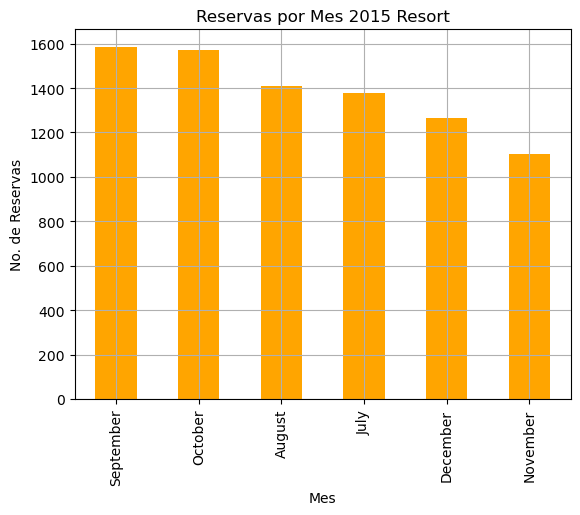

In [12]:
# Se dividirán las reservas entre meses para identificar la temporada alta vs baja por año
resort_2015_by_month = resort[resort['ArrivalDateYear']==2015]
resort_2015_by_month = resort_2015_by_month.groupby('ArrivalDateMonth').size().sort_values(ascending=False)
print(resort_2015_by_month.head())
resort_2015_by_month.plot(kind='bar', color='orange', x='arrival_month', y=0)
plt.title('Reservas por Mes 2015 Resort')
plt.xlabel('Mes')
plt.ylabel('No. de Reservas')
plt.grid(True)
plt.show()

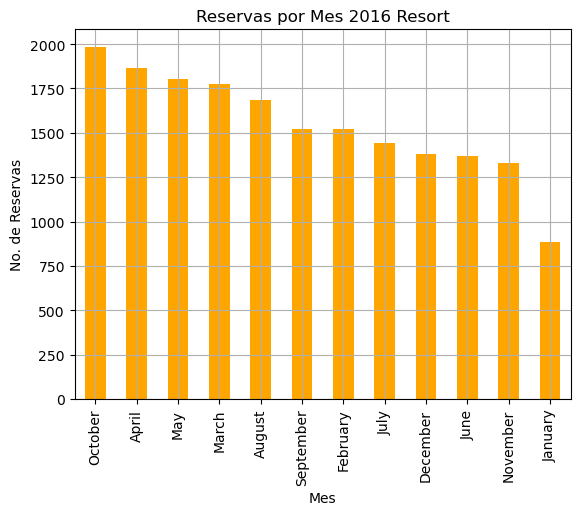

In [13]:
resort_2016_by_month = resort[resort['ArrivalDateYear']==2016]
resort_2016_by_month = resort_2016_by_month.groupby('ArrivalDateMonth').size().sort_values(ascending=False)
resort_2016_by_month.plot(kind='bar', color='orange')
plt.title('Reservas por Mes 2016 Resort')
plt.xlabel('Mes')
plt.ylabel('No. de Reservas')
plt.grid(True)
plt.show()

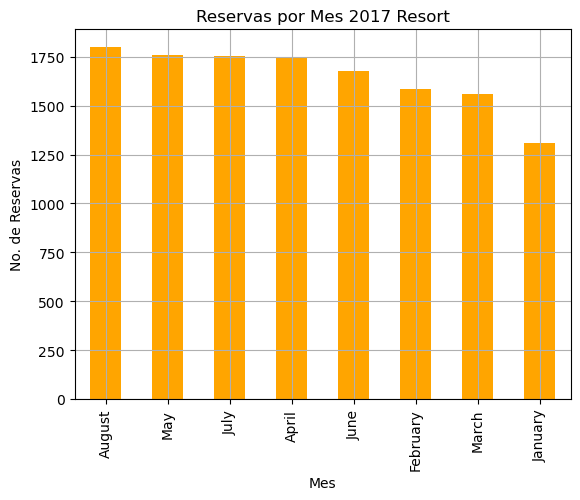

In [14]:
resort_2017_by_month = resort[resort['ArrivalDateYear']==2017]
resort_2017_by_month = resort_2017_by_month.groupby('ArrivalDateMonth').size().sort_values(ascending=False)
resort_2017_by_month.plot(kind='bar', color='orange')
plt.title('Reservas por Mes 2017 Resort')
plt.xlabel('Mes')
plt.ylabel('No. de Reservas')
plt.grid(True)
plt.show()

### City

ArrivalDateMonth
September    3529
October      3386
August       2480
December     1654
July         1398
dtype: int64


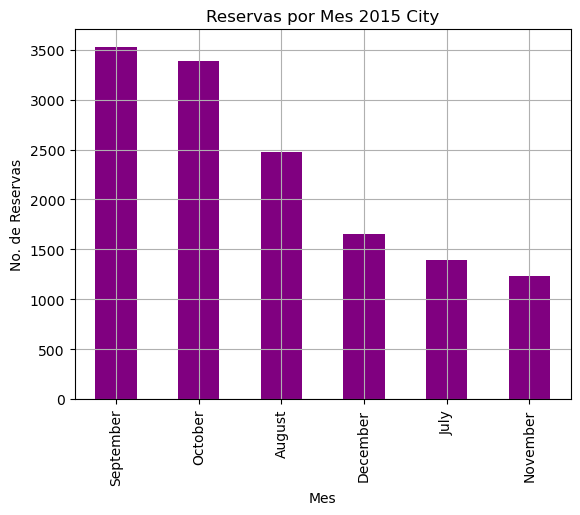

In [15]:
# Se dividirán las reservas entre meses para identificar la temporada alta vs baja por año
city_2015_by_month = city[city['ArrivalDateYear']==2015]
city_2015_by_month = city_2015_by_month.groupby('ArrivalDateMonth').size().sort_values(ascending=False)
print(city_2015_by_month.head())
city_2015_by_month.plot(kind='bar', color='purple', x='arrival_month', y=0)
plt.title('Reservas por Mes 2015 City')
plt.xlabel('Mes')
plt.ylabel('No. de Reservas')
plt.grid(True)
plt.show()

ArrivalDateMonth
October      4219
June         3923
September    3871
May          3676
April        3561
dtype: int64


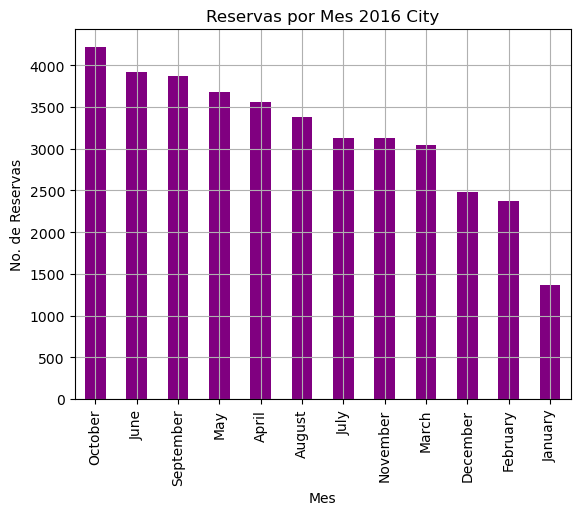

In [16]:
# Se dividirán las reservas entre meses para identificar la temporada alta vs baja por año
city_2016_by_month = city[city['ArrivalDateYear']==2016]
city_2016_by_month = city_2016_by_month.groupby('ArrivalDateMonth').size().sort_values(ascending=False)
print(city_2016_by_month.head())
city_2016_by_month.plot(kind='bar', color='purple', x='arrival_month', y=0)
plt.title('Reservas por Mes 2016 City')
plt.xlabel('Mes')
plt.ylabel('No. de Reservas')
plt.grid(True)
plt.show()

ArrivalDateMonth
May      4556
June     3971
April    3919
July     3559
March    3412
dtype: int64


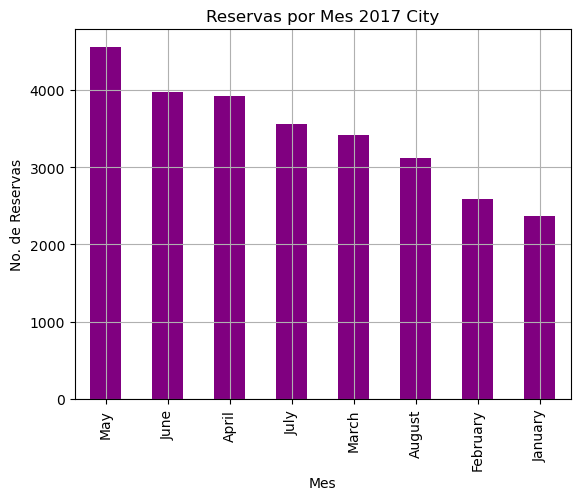

In [17]:
# Se dividirán las reservas entre meses para identificar la temporada alta vs baja por año
city_2017_by_month = city[city['ArrivalDateYear']==2017]
city_2017_by_month = city_2017_by_month.groupby('ArrivalDateMonth').size().sort_values(ascending=False)
print(city_2017_by_month.head())
city_2017_by_month.plot(kind='bar', color='purple', x='arrival_month', y=0)
plt.title('Reservas por Mes 2017 City')
plt.xlabel('Mes')
plt.ylabel('No. de Reservas')
plt.grid(True)
plt.show()

### Observaciones
Considerando que los datos que tenemos no cubren todos los meses de cada año (2015 comienza en julio y 2017 termina en agosto), en los 3 años que tenemos, podemos observar que los meses ocn más reservas son entre abril y octubre, por lo que consideraremos el verano y otoño como la temporada alta del año, y primavera e invierno como la temporada baja.

# 2. ¿Existen diferencias en la estacionalidad entre ambos tipos de hotel?

### Comparación Resort vs City 2015

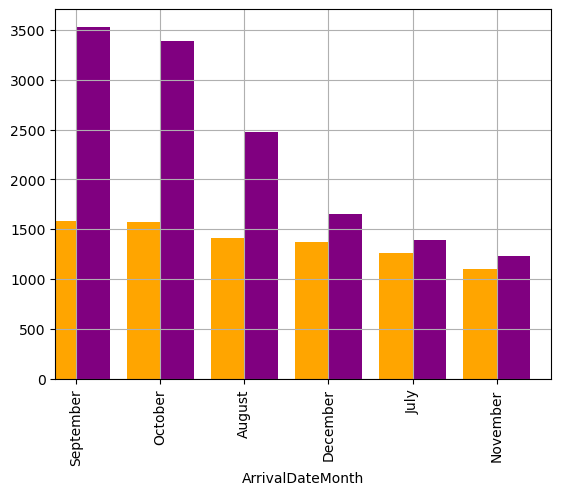

In [18]:
resort_2015_by_month.plot(kind='bar', color='orange', position=1, label='Resort', width=0.4)
city_2015_by_month.plot(kind='bar', color='purple', position=0, label='City', width=0.4)
plt.grid(True)
plt.show()

### Comparación Resort vs City 2016

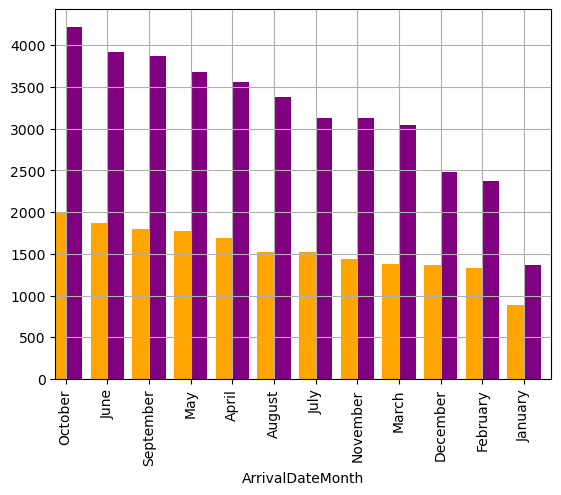

In [19]:
resort_2016_by_month.plot(kind='bar', color='orange', position=1, label='Resort', width=0.4)
city_2016_by_month.plot(kind='bar', color='purple', position=0, label='City', width=0.4)
plt.grid(True)
plt.show()

### Comparación Resort vs City 2017

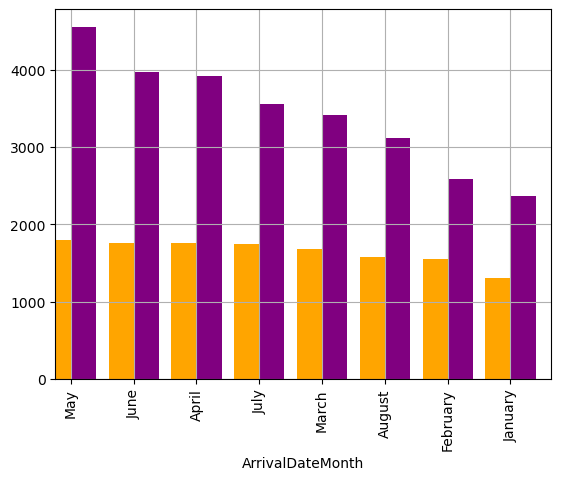

In [20]:
resort_2017_by_month.plot(kind='bar', color='orange', position=1, label='Resort', width=0.4)
city_2017_by_month.plot(kind='bar', color='purple', position=0, label='City', width=0.4)
plt.grid(True)
plt.show()

### Observaciones

Se puede observar que en los 3 años, el hotel City tiene más reservaciones que Resort, pero los dos mantienen la misma tendencia entre temporadas/meses. Es decir, el cliente no prefiere un tipo de hotel sobre otro basándose en la temporada.

# 3. ¿Qué tipo de hotel presenta una mayor tasa de cancelación?

Para observar la tasa de cancelación, haremos un cálculo con la columna 'IsCanceled' para cada hotel

### Cancelación Resort 

In [21]:
canceled_resort = resort['IsCanceled'].sum()
print(canceled_resort)

11122


In [22]:
total_resort_bookings = resort['booking_id'].count()
canceled_resort_rate = canceled_resort/total_resort_bookings
rate = (canceled_resort_rate*100).round(2).item()
print(f'La tasa de cancelación del hotel resort es de',rate,'%')

La tasa de cancelación del hotel resort es de 27.76 %


### Cancelación City

In [23]:
canceled_city = city['IsCanceled'].sum()
print(canceled_city)

33102


In [24]:
total_city_bookings = city['booking_id'].count()
city_cancelation_rate = canceled_city/total_city_bookings
city_rates = (city_cancelation_rate*100).round(2).item()
print(f'La tasa de cancelación del hotel city es de', city_rates,'%')

La tasa de cancelación del hotel city es de 41.73 %


### Observaciones

El hotel City es el que cuenta con una mayor tasa de cancelación, teniendo cerca de la mitad de sus reservaciones canceladas. Con esto podemos confirmar que la cantidad de registros elevada que tiene el dataset del hotel City no necesariamente refleja que sea un hotel más exitoso que el resort. 

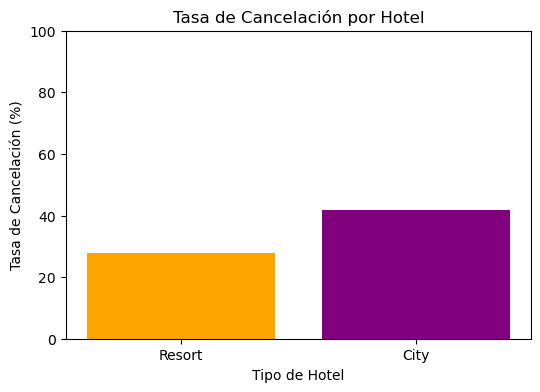

In [25]:
hotels = ['Resort','City']
cancelation_rates = [rate, city_rates]
plt.figure(figsize=(6,4))
plt.bar(hotels, cancelation_rates, color=['orange','purple'])
plt.title('Tasa de Cancelación por Hotel')
plt.xlabel('Tipo de Hotel')
plt.ylabel('Tasa de Cancelación (%)')
plt.ylim(0,100)
plt.show()

EL hotel City muestra una tasa de cancelación considerablemente mayor que el hotel Resort, lo cual representa una mayor volatilidad en las reservas urbanas. 

# 4. ¿La anticipación de reserva influye de manera distinta en las cancelaciones según el tipo de hotel?

Para medir el tiempo de anticipación de la reserva, usaremos la columna LeadTime

#### Resort

In [26]:
# se calculará el promedio de dias de anticipación con el que un cliente hace su reserva
resort_lead_avg = resort['LeadTime'].mean()
print(resort_lead_avg.round(2))

92.68


In [27]:
#se filtrarán las reservas según el lead time promedio
long_lead = resort[(resort['LeadTime'] > resort_lead_avg) & (resort['IsCanceled']==1)].shape[0]
short_lead = resort[(resort['LeadTime'] <= resort_lead_avg) & (resort['IsCanceled']==1)].shape[0]

print(f' Hubo', long_lead, 'reservaciones que tenían una anticipación alta que fueron canceladas ')
print(f' Hubo', short_lead, 'reservaciones que tenían una anticipación baja que fueron canceladas')

 Hubo 6175 reservaciones que tenían una anticipación alta que fueron canceladas 
 Hubo 4947 reservaciones que tenían una anticipación baja que fueron canceladas


In [28]:
# se calculará la tasa de cancelación según la longitud de antelación
long_lead_total = resort[resort['LeadTime'] > resort_lead_avg].shape[0]
short_lead_total = resort[resort['LeadTime'] <=  resort_lead_avg].shape[0]

long_lead_rate = round((long_lead/long_lead_total)*100,2)
short_lead_rate = round((short_lead/short_lead_total)*100,2)

print(f'Las reservaciones con largo tiempo de antelación en el Resort tienen una tasa de cancelación de' ,long_lead_rate, '%')
print(f'Las reservaciones con corto tiempo de antelación en el Resort tienen una tasa de cancelación de', short_lead_rate, '%')

Las reservaciones con largo tiempo de antelación en el Resort tienen una tasa de cancelación de 39.24 %
Las reservaciones con corto tiempo de antelación en el Resort tienen una tasa de cancelación de 20.34 %


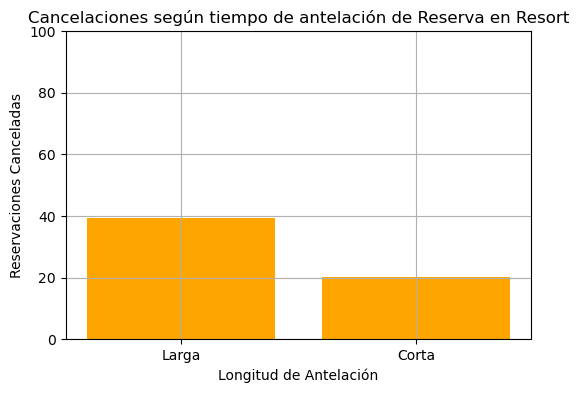

In [29]:
#se graficará la diferencia para mayor visualización
cancelaciones = [long_lead_rate, short_lead_rate]
anticipacion = ['Larga','Corta']

plt.figure(figsize=(6,4))
plt.bar(anticipacion, cancelaciones, color='orange')
plt.xlabel('Longitud de Antelación')
plt.ylabel('Reservaciones Canceladas')
plt.title('Cancelaciones según tiempo de antelación de Reserva en Resort')
plt.ylim(0,100)
plt.grid(True)
plt.show()

Las reservas generadas con mayor tiempo de antelación tienden a tener más cancelaciones que las que se generaron con poca anticipación. Mientras que la diferencia es notable, esto no garantiza que el tiempo de anticipación sea una relación causal directa de su cancelación. 

#### City

In [30]:
# se calculará el promedio de dias de anticipación con el que un cliente hace su reserva
city_lead_avg = city['LeadTime'].mean()
print(city_lead_avg.round(2))

109.74


In [31]:
#se filtrarán las reservas según el lead time promedio
long_lead_c = city[(city['LeadTime'] > city_lead_avg) & (city['IsCanceled']==1)].shape[0]
short_lead_c = city[(city['LeadTime'] <= city_lead_avg) & (city['IsCanceled']==1)].shape[0]

print(f' Hubo', long_lead_c, 'reservaciones que tenían una anticipación alta que fueron canceladas ')
print(f' Hubo', short_lead_c, 'reservaciones que tenían una anticipación baja que fueron canceladas')

 Hubo 17180 reservaciones que tenían una anticipación alta que fueron canceladas 
 Hubo 15922 reservaciones que tenían una anticipación baja que fueron canceladas


In [32]:
# se calculará la tasa de cancelación según la longitud de antelación
long_lead_total_c = city[city['LeadTime'] > city_lead_avg].shape[0]
short_lead_total_c = city[city['LeadTime'] <= city_lead_avg].shape[0]

long_lead_rate_c = round((long_lead_c/long_lead_total_c)*100,2)
short_lead_rate_c = round((short_lead_c/short_lead_total_c)*100,2)

print(f'Las reservaciones con largo tiempo de antelación en el Hotel Urbano tienen una tasa de cancelación de' ,long_lead_rate_c, '%')
print(f'Las reservaciones con corto tiempo de antelación en el Hotel Urbano tienen una tasa de cancelación de', short_lead_rate_c, '%')

Las reservaciones con largo tiempo de antelación en el Hotel Urbano tienen una tasa de cancelación de 56.87 %
Las reservaciones con corto tiempo de antelación en el Hotel Urbano tienen una tasa de cancelación de 32.41 %


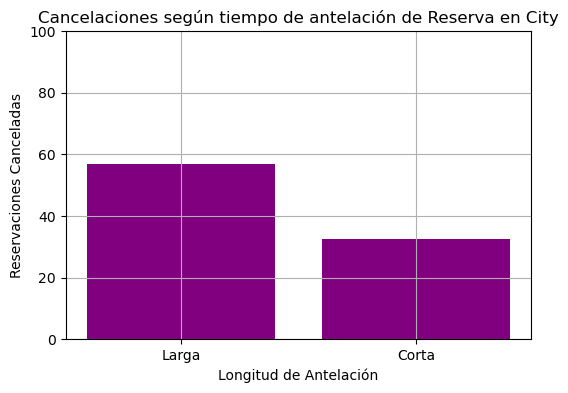

In [33]:
#se graficará la diferencia para mayor visualización
cancelaciones_c = [long_lead_rate_c, short_lead_rate_c]
anticipacion = ['Larga','Corta']

plt.figure(figsize=(6,4))
plt.bar(anticipacion, cancelaciones_c, color='purple')
plt.xlabel('Longitud de Antelación')
plt.ylabel('Reservaciones Canceladas')
plt.title('Cancelaciones según tiempo de antelación de Reserva en City')
plt.ylim(0,100)
plt.grid(True)
plt.show()

Al igual que en el hotel Resort, las reservaciones hechas con mucha antelación para el hotel City, tienen más cancelaciones que las que se generan con poco tiempo de antelación. Algo importante a tomar en cuenta es que las dos tasas en este hotel son mayores a las tasas del hotel Resort. Esto refuerza el argumento anterior de que existen más cancelaciones por reserva en el hotel City. 

# 5. ¿Qué diferencias hay en el precio promedio por noche (ADR) entre cada hotel?

In [34]:
# se caculará el precio promedio por noche del hotel Resort
resort_adr = resort['ADR'].mean().round(2)
print(f'Precio promedio por noche en hotel Resort: ', resort_adr)
# se calculará el precio promedio por noche del hotel City
city_adr = city['ADR'].mean().round(2)
print(f'Precio promedio por noche en hotel City: ',city_adr)

Precio promedio por noche en hotel Resort:  94.95
Precio promedio por noche en hotel City:  105.3


Considerando que en nuestros datasets hay reservas que se cancelaron y no se cobraron, eliminaremos todas las filas que tengan un ADR = 0 para tener una respuesta más precisa. 

In [35]:
# se calculará el precio promedio por noche de ambos hoteles sin considerar las reservaciones que no se cobraron
resort_adr_clean = resort[resort['ADR'] >0]['ADR'].mean().round(2)
print(f'Precio promedio por noche en hotel Resort: ', resort_adr_clean)
city_adr_clean = city[city['ADR'] >0]['ADR'].mean().round(2)
print(f'Precio promedio por noche en hotel City: ', city_adr_clean)

Precio promedio por noche en hotel Resort:  96.77
Precio promedio por noche en hotel City:  106.93


In [36]:
# se calculará la mediana del ADR para mayor claridad
resort_adr_clean = resort[resort['ADR'] >0]['ADR'].median()
print(f'Mediana de precio por noche en hotel Resort: ', resort_adr_clean)
city_adr_clean = city[city['ADR'] >0]['ADR'].median()
print(f'Mediana de precio por noche en hotel City: ', city_adr_clean)

Mediana de precio por noche en hotel Resort:  76.8
Mediana de precio por noche en hotel City:  100.0


#### Observaciones

Sorprendentemente, el hotel City tiene una tarifa promedio diaria más alta que el hotel resort. Esto puede deberse a que este tipo de hotel suele tener más demanda corporativa, viajes rápidos, lo cual lleva a tarifas más establecidads y menos flexibles, mientras que el hotel Resort por lo general es uno que se reserva por temporadas y únicamente para vacaciones: puede tener promociones por tiempo de estadía o paquetes familiares que lleva a una variación de tarifa y precio promedio. 

# Conclusiones

Con este proyecto se pudieron observar algunas diferencias entre las reservaciones y comportamiento de tarifas de dos hoteles con rubros distintos: un hotel Resort y un hotel Urbano. Se pudieron observar las siguientes diferencias:
- Los dos hoteles tuvieron mayor demanda en "temporada alta", la cual cubre verano y otoño y menor demanda en "temproada baja" (invierno y primavera).
- El hotel City tuvo más demanda que el Resort a través del año, los tres años en cuestión.
- El hotel City representó una tasa de cancelación significativamente mayor que el hotel Resort.
- Una anticipación de reserva alargada tiende a resultar en mayor probabilidad de cancelación en ambos hoteles.
- El hotel City en cuestión tiene una mayor ADR (Precio Promedio por Noche) que el hotel Resort en este estudio.

Recomendaciones:
- Hay un área de oportunidad en las reservaciones con larga anticipación. Quizás mandar recordatorios al cliente de su reserva, u ofrecer un descuento. 
- Hay una gran tasa de cancelación en el hotel City, representando un 41% de sus reservaciones. Esto es algo a tomar en cuenta para el futuro. 